# MDR-TS v21.5
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** 
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** May 22, 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v21.5
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** Delta of `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Jupyter Lab + VS Code

---

**What's new?**

- Experts blow in practice. Building an ensamble with weights that are learned from the data is better than picking one expert or using a simple average.
- Predicting the delta of soil moisture instead of the absolute value directly.

## Imports

In [6]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import xgboost as xgb

import torch
import pickle

PROJECT_ROOT = os.path.abspath("../../")
print(f"project_root: {PROJECT_ROOT}")
if PROJECT_ROOT not in sys.path:
    # sys.path.insert(0, PROJECT_ROOT)
    sys.path.append(PROJECT_ROOT)

try:
    from Models.Utils.dashboard import metrics_dashboard
except ImportError as e:
    from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

project_root: C:\Users\pan\Documents\GitHub\MDR-Project
imports loaded
using: cpu


In [7]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def _gpu_available():
    try:
        import subprocess
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True, text=True, timeout=5
        )
        return result.returncode == 0 and bool(result.stdout.strip())
    except Exception:
        return False

HAS_GPU = _gpu_available()

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print(f"  GPU available: {HAS_GPU}")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.12.8
  NumPy version:  2.4.4
  Pandas version: 3.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: True
environment setup complete


In [8]:
VERSION    = "v21"
SUBVERSION = "v21.5"
RUN_NAME   = "mdr_ts_v21_5"

DATA_ROOT    = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT   = f"{DATA_ROOT}/splits"
OUTPUT_ROOT  = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",   os.path.exists(DATA_ROOT))
print("  splits exists:", os.path.exists(SPLIT_ROOT))
print("  output exists:", os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: C:\Users\pan\Documents\GitHub\MDR-Project
  DATA_ROOT:    C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data
  SPLIT_ROOT:   C:\Users\pan\Documents\GitHub\MDR-Project/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  C:\Users\pan\Documents\GitHub\MDR-Project/Models/Temporal/v21/v21.5

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [9]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# --- Create delta target (day-over-day first difference) ---
Y_LAG1_COL = "soil_moisture_5cm_lag1"
TARGET_DELTA_COL = "delta_soil_moisture_5cm"
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values(["station_id", "date"], inplace=True)
    df[Y_LAG1_COL] = df.groupby("station_id")["soil_moisture_5cm"].shift(1)
    df[TARGET_DELTA_COL] = df["soil_moisture_5cm"] - df[Y_LAG1_COL]
    df.dropna(subset=[TARGET_DELTA_COL], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"train rows after delta: {len(train_df)}")
print(f"val   rows after delta: {len(val_df)}")
print(f"test  rows after delta: {len(test_df)}")

Split files:
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\train.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\val.csv
  C:\Users\pan\Documents\GitHub\MDR-Project\Temporal\Pipeline\data\splits\derived_8.0\test.csv
train rows after delta: 6863
val   rows after delta: 2716
test  rows after delta: 4011


In [10]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 501

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


## Features

In [11]:
TARGET_COL = "soil_moisture_5cm"
TARGET_DELTA_COL = "delta_soil_moisture_5cm"
Y_LAG1_COL = "soil_moisture_5cm_lag1"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

### Transition

In [12]:
FEATURE_COLS_TRANSITION = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "SMAP_sm_interp_lag1",
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollmean7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs14",
    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",
    "V_rollmean_s2_b11_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",
    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

### Dry

In [13]:
FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "G_DSLR",

    "V_rollmean_s2_b11_kobs7",
    "year_frac", "sin_year", "cos_year",
]


### Wet

In [14]:
FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "SMAP_sm_interp_lag7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",

    "G_rain_sum_30d",

    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "slope", "elev",
]

### Interaction Features

### New: WET

In [15]:
INTERACTION_SPECS = {
    "wet_rain7_x_LST": ("G_rain_sum_7d", "LST"),
    "wet_api_x_LST": ("G_API", "LST"),
    "wet_rain7_x_NDMI": ("G_rain_sum_7d", "F_NDMI"),
    "wet_rain7_x_slope": ("G_rain_sum_7d", "slope"),
    "wet_smaplag7_x_sin_year": ("SMAP_sm_interp_lag7", "sin_year"),
    "wet_smaplag7_x_cos_year": ("SMAP_sm_interp_lag7", "cos_year"),
}

dfs = {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}

created_features = []
skipped_features = []

for new_col, (col_a, col_b) in INTERACTION_SPECS.items():
    missing = []
    for split_name, df in dfs.items():
        for col in (col_a, col_b):
            if col not in df.columns and col not in missing:
                missing.append(col)

    if missing:
        skipped_features.append((new_col, tuple(missing)))
        continue

    for split_name, df in dfs.items():
        df[new_col] = df[col_a] * df[col_b]

    created_features.append(new_col)

print("Created interaction features:")
for c in created_features:
    print("  ", c)

if skipped_features:
    print("\nSkipped features due to missing source columns:")
    for feat, missing in skipped_features:
        print(f"  {feat}: missing {missing}")

train_df["wet_indicator_proxy"] = (train_df["G_rain_sum_7d"] + train_df["G_API"])
val_df["wet_indicator_proxy"] = (val_df["G_rain_sum_7d"] + val_df["G_API"])
test_df["wet_indicator_proxy"] = (test_df["G_rain_sum_7d"] + test_df["G_API"])

FEATURE_COLS_WET = FEATURE_COLS_WET + [c for c in created_features if c not in FEATURE_COLS_WET]

print("new wet feature count:", len(FEATURE_COLS_WET))
print("added to wet model:", [c for c in created_features if c in FEATURE_COLS_WET])

Created interaction features:
   wet_rain7_x_NDMI
   wet_rain7_x_slope
   wet_smaplag7_x_sin_year
   wet_smaplag7_x_cos_year

Skipped features due to missing source columns:
  wet_rain7_x_LST: missing ('LST',)
  wet_api_x_LST: missing ('LST',)
new wet feature count: 32
added to wet model: ['wet_rain7_x_NDMI', 'wet_rain7_x_slope', 'wet_smaplag7_x_sin_year', 'wet_smaplag7_x_cos_year']


### New: Transition

In [16]:
train_df["tr_api_x_lst"] = train_df["G_API"] * train_df["LST_modis"]
val_df["tr_api_x_lst"]   = val_df["G_API"] * val_df["LST_modis"]
test_df["tr_api_x_lst"]  = test_df["G_API"] * test_df["LST_modis"]

train_df["tr_api_x_slope"] = train_df["G_API"] * train_df["slope"]
val_df["tr_api_x_slope"]   = val_df["G_API"] * val_df["slope"]
test_df["tr_api_x_slope"]  = test_df["G_API"] * test_df["slope"]

train_df["tr_smap_x_season"] = train_df["SMAP_sm_interp"] * train_df["sin_year"]
val_df["tr_smap_x_season"]   = val_df["SMAP_sm_interp"] * val_df["sin_year"]
test_df["tr_smap_x_season"]  = test_df["SMAP_sm_interp"] * test_df["sin_year"]

FEATURE_COLS_TRANSITION += [
    "tr_api_x_lst",
    "tr_api_x_slope",
    "tr_smap_x_season"
]

In [17]:
def _check_cols(df, cols, name):
    missing = sorted(set(cols) - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns in {name}: {missing}")

for _df_name, _df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    _check_cols(_df, KEEP_META_COLS + [TARGET_COL], _df_name)
    _check_cols(_df, FEATURE_COLS_TRANSITION, f"{_df_name} (BASE)")
    _check_cols(_df, FEATURE_COLS_DRY, f"{_df_name} (DRY)")
    _check_cols(_df, FEATURE_COLS_WET, f"{_df_name} (WET)")

print("Columns locked")
print("  BASE features:", len(FEATURE_COLS_TRANSITION))
print("  DRY  features:", len(FEATURE_COLS_DRY))
print("  WET  features:", len(FEATURE_COLS_WET))
print("  Target:", TARGET_COL)

Columns locked
  BASE features: 37
  DRY  features: 22
  WET  features: 32
  Target: soil_moisture_5cm


## Utils

In [18]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 15

def plot_top_features(model, feature_cols, title):
    imp = get_xgb_importance(model, feature_cols)
    imp_top = imp.sort_values(ascending=False).head(TOP_K)

    print(f"\n{title} - Top {TOP_K} Features")
    print("=" * 50)
    print(imp_top.to_string())

    plt.figure(figsize=(6, max(4, 0.4 * TOP_K)))
    y = np.arange(len(imp_top))

    plt.barh(y, imp_top.values)
    plt.yticks(y, imp_top.index)
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

### Split

In [19]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6863
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-02 00:00:00 -- 2020-12-31 00:00:00

VAL
  rows:     2716
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-02 00:00:00 -- 2022-12-31 00:00:00

TEST
  rows:     4011
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-02 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [20]:
y_train = train_df[TARGET_DELTA_COL].copy()
y_val = val_df[TARGET_DELTA_COL].copy()
y_test = test_df[TARGET_DELTA_COL].copy()

y_lag1_train = train_df[Y_LAG1_COL].copy()
y_lag1_val   = val_df[Y_LAG1_COL].copy()
y_lag1_test  = test_df[Y_LAG1_COL].copy()

y_abs_train = train_df[TARGET_COL].copy()
y_abs_val   = val_df[TARGET_COL].copy()
y_abs_test  = test_df[TARGET_COL].copy()

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
y_trainval = trainval_df[TARGET_DELTA_COL].copy()

X_train_dry = train_df[FEATURE_COLS_DRY].copy()
X_val_dry = val_df[FEATURE_COLS_DRY].copy()
X_test_dry = test_df[FEATURE_COLS_DRY].copy()

X_trainval_dry = trainval_df[FEATURE_COLS_DRY].copy()

X_train_transition = train_df[FEATURE_COLS_TRANSITION].copy()
X_val_transition = val_df[FEATURE_COLS_TRANSITION].copy()
X_test_transition = test_df[FEATURE_COLS_TRANSITION].copy()

X_trainval_transition = trainval_df[FEATURE_COLS_TRANSITION].copy()

X_train_wet = train_df[FEATURE_COLS_WET].copy()
X_val_wet = val_df[FEATURE_COLS_WET].copy()
X_test_wet = test_df[FEATURE_COLS_WET].copy()

X_trainval_wet = trainval_df[FEATURE_COLS_WET].copy()

print("\nMatrix shapes:")
print("  DRY        train:", X_train_dry.shape,        "val:", X_val_dry.shape,        "test:", X_test_dry.shape)
print("  TRANSITION train:", X_train_transition.shape, "val:", X_val_transition.shape, "test:", X_test_transition.shape)
print("  WET        train:", X_train_wet.shape,        "val:", X_val_wet.shape,        "test:", X_test_wet.shape)

print("\nTrain+Val shapes:")
print("  y_trainval:", y_trainval.shape)
print("  DRY       trainval:", X_trainval_dry.shape)
print("  TRANSITION trainval:", X_trainval_transition.shape)
print("  WET       trainval:", X_trainval_wet.shape)

print(f"Target: delta of {TARGET_COL} ({TARGET_DELTA_COL})")
print(f"Regime baseline: {Y_LAG1_COL}")


Matrix shapes:
  DRY        train: (6863, 22) val: (2716, 22) test: (4011, 22)
  TRANSITION train: (6863, 37) val: (2716, 37) test: (4011, 37)
  WET        train: (6863, 32) val: (2716, 32) test: (4011, 32)

Train+Val shapes:
  y_trainval: (9579,)
  DRY       trainval: (9579, 22)
  TRANSITION trainval: (9579, 37)
  WET       trainval: (9579, 32)
Target: delta of soil_moisture_5cm (delta_soil_moisture_5cm)
Regime baseline: soil_moisture_5cm_lag1


### Inner Split

In [21]:
# SUPER IMPORTANT
# 0: dry
# 1: transition
# 2: wet

t1 = 0.20   # 33rd percentile / dry threshold
t2 = 0.313  # 66th percentile / wet threshold

def assign_regime(y, t1=0.20, t2=0.313):
    y_arr = np.asarray(y).ravel()
    reg = np.zeros_like(y_arr, dtype=int)
    reg[(y_arr > t1) & (y_arr <= t2)] = 1
    reg[y_arr > t2] = 2
    return reg

# Regime classification uses y_lag1 (previous day's absolute value)
reg_train = assign_regime(y_lag1_train, t1, t2)
reg_val   = assign_regime(y_lag1_val, t1, t2)
reg_test  = assign_regime(y_lag1_test, t1, t2)

mask_train_dry = (reg_train == 0)
mask_train_transition = (reg_train == 1)
mask_train_wet = (reg_train == 2)

mask_val_dry = (reg_val == 0)
mask_val_transition = (reg_val == 1)
mask_val_wet = (reg_val == 2)

mask_test_dry = (reg_test == 0)
mask_test_transition = (reg_test == 1)
mask_test_wet = (reg_test == 2)

y_train_dry = np.asarray(y_train)[mask_train_dry]
y_train_transition = np.asarray(y_train)[mask_train_transition]
y_train_wet = np.asarray(y_train)[mask_train_wet]

y_val_dry = np.asarray(y_val)[mask_val_dry]
y_val_transition = np.asarray(y_val)[mask_val_transition]
y_val_wet = np.asarray(y_val)[mask_val_wet]

y_test_dry = np.asarray(y_test)[mask_test_dry]
y_test_transition = np.asarray(y_test)[mask_test_transition]
y_test_wet = np.asarray(y_test)[mask_test_wet]

print("Train regime counts (via y_lag1):", {
    "dry": int(mask_train_dry.sum()),
    "transition": int(mask_train_transition.sum()),
    "wet": int(mask_train_wet.sum())
})
print("Val regime counts (via y_lag1):", {
    "dry": int(mask_val_dry.sum()),
    "transition": int(mask_val_transition.sum()),
    "wet": int(mask_val_wet.sum())
})
print("Test regime counts (via y_lag1):", {
    "dry": int(mask_test_dry.sum()),
    "transition": int(mask_test_transition.sum()),
    "wet": int(mask_test_wet.sum())
})

Train regime counts (via y_lag1): {'dry': 3292, 'transition': 2725, 'wet': 846}
Val regime counts (via y_lag1): {'dry': 987, 'transition': 1154, 'wet': 575}
Test regime counts (via y_lag1): {'dry': 1508, 'transition': 2011, 'wet': 492}


### Dry Model

In [22]:
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

X_train_dry_regime = X_train_dry.loc[reg_train == 0].copy()
X_val_dry_regime   = X_val_dry.loc[reg_val == 0].copy()
X_test_dry_regime  = X_test_dry.loc[reg_test == 0].copy()

y_train_dry = y_train.loc[reg_train == 0].copy()
y_val_dry   = y_val.loc[reg_val == 0].copy()
y_test_dry  = y_test.loc[reg_test == 0].copy()

dry_model = xgb.XGBRegressor(**XGB_PARAMS_DRY)

dry_model.fit(
    X_train_dry_regime,
    y_train_dry,
    eval_set=[(X_val_dry_regime, y_val_dry)],
    verbose=False
)

pred_dry_train = dry_model.predict(X_train_dry_regime)
pred_dry_val   = dry_model.predict(X_val_dry_regime)
pred_dry_test  = dry_model.predict(X_test_dry_regime)


Dry Model - Top 15 Features
SMAP_sm_interp_diff1          0.063598
K_slope_cos                   0.057774
K_slope_sin                   0.051477
J_clay_wfrac_b0               0.049602
K_aspect_cos                  0.049590
slope                         0.048251
J_sand_wfrac_b0               0.048211
cos_year                      0.046639
V_rollmean_s2_b11_kobs7       0.045169
V_rollmin_LST_modis_kobs30    0.045160
A_d_LST_modis_kobs14          0.044871
C_lag_G_API_kobs1             0.044825
elev                          0.044790
sin_year                      0.044757
year_frac                     0.043932


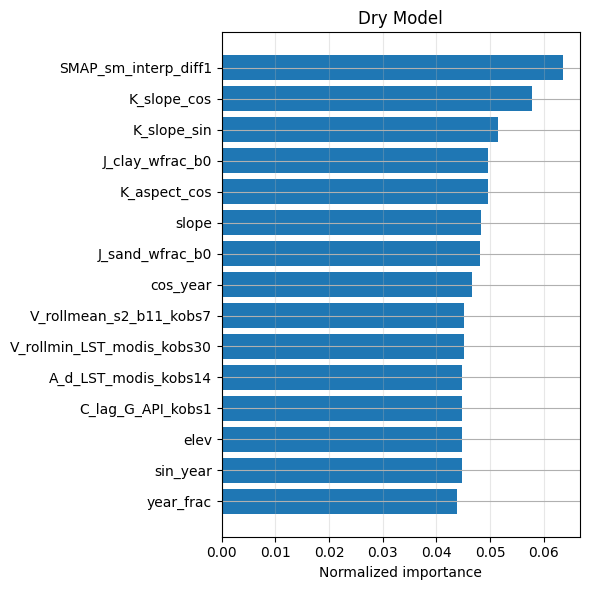

In [23]:
plot_top_features(dry_model, FEATURE_COLS_DRY, "Dry Model")

### Wet Model

In [24]:
XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=4,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=0.8,
    n_estimators=2500,
    learning_rate=0.03,
    reg_lambda=1.5,
    reg_alpha=0.0,
)

X_train_wet_regime = X_train_wet.loc[reg_train == 2].copy()
X_val_wet_regime   = X_val_wet.loc[reg_val == 2].copy()
X_test_wet_regime  = X_test_wet.loc[reg_test == 2].copy()

y_train_wet = y_train.loc[reg_train == 2].copy()
y_val_wet   = y_val.loc[reg_val == 2].copy()
y_test_wet  = y_test.loc[reg_test == 2].copy()

wet_model = xgb.XGBRegressor(**XGB_PARAMS_WET)

wet_model.fit(
    X_train_wet_regime,
    y_train_wet,
    eval_set=[(X_val_wet_regime, y_val_wet)],
    verbose=False
)

pred_wet_train = wet_model.predict(X_train_wet_regime)
pred_wet_val   = wet_model.predict(X_val_wet_regime)
pred_wet_test  = wet_model.predict(X_test_wet_regime)


Wet Model - Top 15 Features
sin_year                       0.074644
SMAP_sm_interp_lag7            0.065552
wet_smaplag7_x_cos_year        0.061403
wet_smaplag7_x_sin_year        0.056398
year_frac                      0.046531
A_d_E_SAR_diff_kobs7           0.039764
elev                           0.039235
slope                          0.038173
A_d_SMAP_sm_interp_kobs7       0.034124
A_grad_E_SAR_ratio_kobs7       0.031332
A_grad_SMAP_sm_interp_kobs7    0.029759
A_grad_E_SAR_diff_kobs7        0.028286
SMAP_sm_interp_diff1           0.027509
SMAP_sm_interp_rollrange7      0.027445
V_rollstd_G_API_kobs7          0.026940


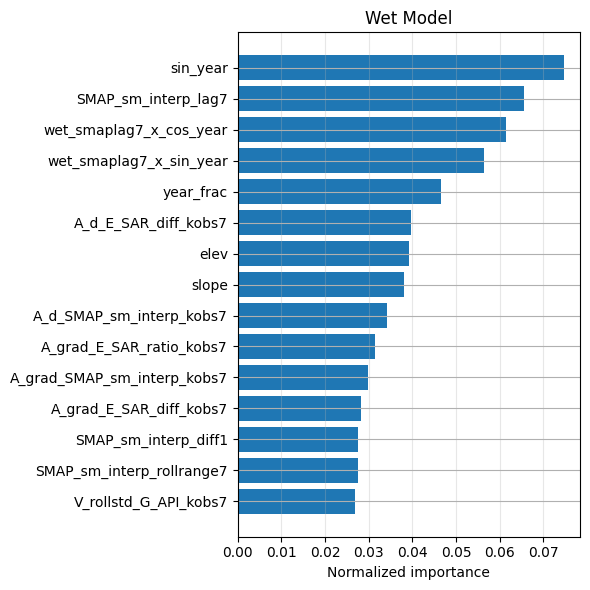

In [25]:
plot_top_features(wet_model, FEATURE_COLS_WET, "Wet Model")

### Transition Model

In [26]:
XGB_PARAMS_TRANSITION = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=5,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=4000,
    learning_rate=0.03,
    reg_lambda=3.0,
    reg_alpha=0.05,
)

X_train_transition_regime = X_train_transition.loc[reg_train == 1].copy()
X_val_transition_regime   = X_val_transition.loc[reg_val == 1].copy()
X_test_transition_regime  = X_test_transition.loc[reg_test == 1].copy()

y_train_transition = y_train.loc[reg_train == 1].copy()
y_val_transition   = y_val.loc[reg_val == 1].copy()
y_test_transition  = y_test.loc[reg_test == 1].copy()

# clean the NaNs so XGB stops complaining - TODO: clean earlier than here
train_valid = (
    np.isfinite(y_train_transition.to_numpy()) &
    np.isfinite(X_train_transition_regime.to_numpy()).all(axis=1)
)

val_valid = (
    np.isfinite(y_val_transition.to_numpy()) &
    np.isfinite(X_val_transition_regime.to_numpy()).all(axis=1)
)

test_valid = (
    np.isfinite(y_test_transition.to_numpy()) &
    np.isfinite(X_test_transition_regime.to_numpy()).all(axis=1)
)

X_train_transition_regime = X_train_transition_regime.loc[train_valid].copy()
X_val_transition_regime   = X_val_transition_regime.loc[val_valid].copy()
X_test_transition_regime  = X_test_transition_regime.loc[test_valid].copy()

y_train_transition = y_train_transition.loc[train_valid].copy()
y_val_transition   = y_val_transition.loc[val_valid].copy()
y_test_transition  = y_test_transition.loc[test_valid].copy()

print("transition rows kept:")
print(" train:", len(y_train_transition), "| dropped:", (~train_valid).sum())
print(" val  :", len(y_val_transition), "| dropped:", (~val_valid).sum())
print(" test :", len(y_test_transition), "| dropped:", (~test_valid).sum())

transition_model = xgb.XGBRegressor(**XGB_PARAMS_TRANSITION)

transition_model.fit(
    X_train_transition_regime,
    y_train_transition,
    eval_set=[(X_val_transition_regime, y_val_transition)],
    verbose=False
)

pred_transition_train = transition_model.predict(X_train_transition_regime)
pred_transition_val   = transition_model.predict(X_val_transition_regime)
pred_transition_test  = transition_model.predict(X_test_transition_regime)

transition rows kept:
 train: 2331 | dropped: 394
 val  : 1154 | dropped: 0
 test : 1887 | dropped: 124



Transition Model - Top 15 Features
elev                          0.054121
J_clay_wfrac_b0               0.036858
J_sand_wfrac_b0               0.033953
SMAP_sm_interp_diff1          0.030452
V_rollmean_G_API_kobs7        0.029947
V_ema_LST_modis_kobs7         0.029720
tr_api_x_lst                  0.029584
V_rollmin_LST_modis_kobs30    0.028370
tr_smap_x_season              0.028153
API_x_year                    0.028042
V_ema_G_API_kobs7             0.027676
SMAP_x_year                   0.027592
tr_api_x_slope                0.027526
V_rollmean_G_API_kobs14       0.027351
G_rain_sum_3d                 0.026999


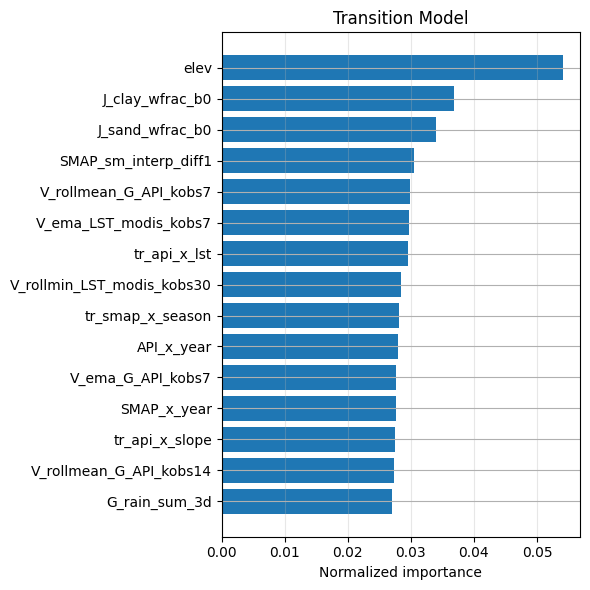

In [27]:
plot_top_features(transition_model, FEATURE_COLS_TRANSITION, "Transition Model")

In [28]:
metrics_dashboard(
    y_val_dry,
    pred_dry_val,
    name="DRY EXPERT ON DRY VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_transition,
    pred_transition_val,
    name="TRANSITION EXPERT ON TRANSITION VAL ROWS",
    return_dict=False
)

metrics_dashboard(
    y_val_wet,
    pred_wet_val,
    name="WET EXPERT ON WET VAL ROWS",
    return_dict=False
)

In [29]:
neat_print(
    get_metrics_dict(y_val_dry, pred_dry_val, prefix=""),
    "DRY REGIME"
)

neat_print(
    get_metrics_dict(y_val_wet, pred_wet_val, prefix=""),
    "WET REGIME"
)

neat_print(
    get_metrics_dict(y_val_transition, pred_transition_val, prefix=""),
    "TRANSITION REGIME"
)


DRY REGIME
Metric                          Value
------------------------------------------
n                                 987
r2                            0.29232
mae                           0.00530
rmse                          0.01024
ubrmse                        0.01024
bias                         -0.00014
med_ae                        0.00236
p90_ae                        0.01323
q05_err                      -0.01342
q50_err                      -0.00012
q95_err                       0.01239

WET REGIME
Metric                          Value
------------------------------------------
n                                 575
r2                           -0.13558
mae                           0.01210
rmse                          0.01696
ubrmse                        0.01681
bias                          0.00223
med_ae                        0.00828
p90_ae                        0.02819
q05_err                      -0.02275
q50_err                       0.00138
q95_err         

### Residuals

In [30]:
# TODO for all

## Diagnostics

### Utils

In [31]:
def soft_weights_asym(signal, t1, t2, w1, w2):
    signal = np.asarray(signal)

    w_dry = np.zeros_like(signal, dtype=float)
    w_transition = np.zeros_like(signal, dtype=float)
    w_wet = np.zeros_like(signal, dtype=float)

    for i, s in enumerate(signal):
        if s <= t1 - w1:
            w_dry[i] = 1.0

        elif s < t1 + w1:
            alpha = (s - (t1 - w1)) / (2 * w1)
            w_dry[i] = 1.0 - alpha
            w_transition[i] = alpha

        elif s <= t2 - w2:
            w_transition[i] = 1.0

        elif s < t2 + w2:
            alpha = (s - (t2 - w2)) / (2 * w2)
            w_transition[i] = 1.0 - alpha
            w_wet[i] = alpha

        else:
            w_wet[i] = 1.0

    return w_dry, w_transition, w_wet

def expert_confidence_from_signal(signal, t1, t2, c1, c2):
    signal = np.asarray(signal)

    dist_t1 = np.abs(signal - t1)
    dist_t2 = np.abs(signal - t2)

    conf_t1 = np.clip(dist_t1 / c1, 0.0, 1.0)
    conf_t2 = np.clip(dist_t2 / c2, 0.0, 1.0)

    # low near either threshold, high far from both
    return np.minimum(conf_t1, conf_t2)


def agreement_confidence(pred_dry, pred_transition, pred_wet, s0):
    preds = np.column_stack([pred_dry, pred_transition, pred_wet])
    spread = np.nanstd(preds, axis=1)

    # high spread -> low confidence
    conf = 1.0 - np.clip(spread / s0, 0.0, 1.0)
    return conf, spread

### Base Model

In [32]:
dry_model_final = dry_model
transition_model_final = transition_model
wet_model_final = wet_model

In [33]:
model_candidates = [
    Path(PROJECT_ROOT) / "Models/Temporal/BEST_MODEL/best_model.pkl",
    Path(PROJECT_ROOT) / "Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260127_210955/model.pkl",
]
model_candidates.extend(
    sorted(
        (Path(PROJECT_ROOT) / "Models/Temporal/v6/v6.1").glob("mdr_ts_rf_v6_1_*/model.pkl"),
        reverse=True,
    )
)

best_model_path = next((path for path in model_candidates if path.exists()), None)
if best_model_path is None:
    raise FileNotFoundError(
        "No gating model found. Checked BEST_MODEL/best_model.pkl and v6/v6.1 model.pkl artifacts."
    )

with open(best_model_path, "rb") as f:
    base_model = pickle.load(f)

if hasattr(base_model, "feature_names_in_") and base_model.feature_names_in_ is not None:
    gate_feature_cols = list(base_model.feature_names_in_)
elif hasattr(base_model, "get_booster") and base_model.get_booster().feature_names is not None:
    gate_feature_cols = list(base_model.get_booster().feature_names)
else:
    raise ValueError(f"could not recover feature names from {best_model_path}")

missing_val  = [c for c in gate_feature_cols if c not in val_df.columns]
missing_test = [c for c in gate_feature_cols if c not in test_df.columns]

if missing_val or missing_test:
    raise ValueError(f"gating features missing from val: {missing_val}  test: {missing_test}")

X_val_gate  = val_df[gate_feature_cols].copy()
X_test_gate = test_df[gate_feature_cols].copy()

pred_val_base  = base_model.predict(X_val_gate)
pred_test_base = base_model.predict(X_test_gate)

print(f"base model path: {best_model_path}")
print(f"base model: {type(base_model).__name__}  features: {len(gate_feature_cols)}")
print(f"val  pred range: [{pred_val_base.min():.3f}, {pred_val_base.max():.3f}]")
print(f"test pred range: [{pred_test_base.min():.3f}, {pred_test_base.max():.3f}]")

base model path: C:\Users\pan\Documents\GitHub\MDR-Project\Models\Temporal\v6\v6.1\mdr_ts_rf_v6_1_20260111_012146\model.pkl
base model: RandomForestRegressor  features: 39
val  pred range: [0.028, 0.389]
test pred range: [0.021, 0.347]


In [34]:
reg_val_pred = assign_regime(pred_val_base, t1, t2)
reg_test_pred = assign_regime(pred_test_base, t1, t2)

print("Predicted regime counts (VAL): ", {r: int((reg_val_pred == r).sum()) for r in [0, 1, 2]})
print("Predicted regime counts (TEST):", {r: int((reg_test_pred == r).sum()) for r in [0, 1, 2]})

print("\nVAL percentiles:  ", np.percentile(pred_val_base, [5, 25, 50, 75, 95]))
print("TEST percentiles: ", np.percentile(pred_test_base, [5, 25, 50, 75, 95]))

Predicted regime counts (VAL):  {0: 975, 1: 1220, 2: 521}
Predicted regime counts (TEST): {0: 1699, 1: 2040, 2: 272}

VAL percentiles:   [0.0436856  0.11208963 0.25441059 0.30259923 0.34061147]
TEST percentiles:  [0.0426967  0.12623572 0.22168337 0.27704339 0.31680795]


In [35]:
pred_val_deploy_soft = np.full(len(y_val), np.nan, dtype=float)
pred_test_deploy_soft = np.full(len(y_test), np.nan, dtype=float)

#### VAL

In [36]:
y_lag1_val_full = val_df[Y_LAG1_COL].to_numpy()

# dry
X_val_dry_full = val_df[FEATURE_COLS_DRY].copy()
valid_dry_val = np.isfinite(X_val_dry_full.to_numpy()).all(axis=1)

pred_val_dry_full = np.full(len(y_val), np.nan, dtype=float)
pred_dry_delta = dry_model_final.predict(X_val_dry_full.loc[valid_dry_val])
pred_val_dry_full[valid_dry_val] = pred_dry_delta + y_lag1_val_full[valid_dry_val]

# transition
X_val_transition_full = val_df[FEATURE_COLS_TRANSITION].copy()
valid_transition_val = np.isfinite(X_val_transition_full.to_numpy()).all(axis=1)

pred_val_transition_full = np.full(len(y_val), np.nan, dtype=float)
pred_transition_delta = transition_model_final.predict(X_val_transition_full.loc[valid_transition_val])
pred_val_transition_full[valid_transition_val] = pred_transition_delta + y_lag1_val_full[valid_transition_val]

# wet
X_val_wet_full = val_df[FEATURE_COLS_WET].copy()
valid_wet_val = np.isfinite(X_val_wet_full.to_numpy()).all(axis=1)

pred_val_wet_full = np.full(len(y_val), np.nan, dtype=float)
pred_wet_delta = wet_model_final.predict(X_val_wet_full.loc[valid_wet_val])
pred_val_wet_full[valid_wet_val] = pred_wet_delta + y_lag1_val_full[valid_wet_val]

#### TEST

In [37]:
y_lag1_test_full = test_df[Y_LAG1_COL].to_numpy()

# dry
X_test_dry_full = test_df[FEATURE_COLS_DRY].copy()
valid_dry_test = np.isfinite(X_test_dry_full.to_numpy()).all(axis=1)

pred_test_dry_full = np.full(len(y_test), np.nan, dtype=float)
pred_dry_delta = dry_model_final.predict(X_test_dry_full.loc[valid_dry_test])
pred_test_dry_full[valid_dry_test] = pred_dry_delta + y_lag1_test_full[valid_dry_test]

# transition
X_test_transition_full = test_df[FEATURE_COLS_TRANSITION].copy()
valid_transition_test = np.isfinite(X_test_transition_full.to_numpy()).all(axis=1)

pred_test_transition_full = np.full(len(y_test), np.nan, dtype=float)
pred_transition_delta = transition_model_final.predict(X_test_transition_full.loc[valid_transition_test])
pred_test_transition_full[valid_transition_test] = pred_transition_delta + y_lag1_test_full[valid_transition_test]

# wet
X_test_wet_full = test_df[FEATURE_COLS_WET].copy()
valid_wet_test = np.isfinite(X_test_wet_full.to_numpy()).all(axis=1)

pred_test_wet_full = np.full(len(y_test), np.nan, dtype=float)
pred_wet_delta = wet_model_final.predict(X_test_wet_full.loc[valid_wet_test])
pred_test_wet_full[valid_wet_test] = pred_wet_delta + y_lag1_test_full[valid_wet_test]

### Ensemble

In [38]:
# hyper params
t1 = 0.191
t2 = 0.291

w1 = 0.05
w2 = 0.12

c1 = 0.03
c2 = 0.08

s0 = 0.04          # disagreement tolerance
lambda_max = 0.25  # max expert influence

# VAL
w_dry_val, w_transition_val, w_wet_val = soft_weights_asym(
    pred_val_base, t1, t2, w1, w2
)

pred_val_expert_mix = (
    w_dry_val * pred_val_dry_full +
    w_transition_val * pred_val_transition_full +
    w_wet_val * pred_val_wet_full
)

conf_val_dist = expert_confidence_from_signal(pred_val_base, t1, t2, c1, c2)
conf_val_agree, spread_val = agreement_confidence(
    pred_val_dry_full, pred_val_transition_full, pred_val_wet_full, s0
)

conf_val = conf_val_dist * conf_val_agree
alpha_val = lambda_max * conf_val

pred_val_ensemble = pred_val_base + alpha_val * (pred_val_expert_mix - pred_val_base)

# TEST
w_dry_test, w_transition_test, w_wet_test = soft_weights_asym(
    pred_test_base, t1, t2, w1, w2
)

pred_test_expert_mix = (
    w_dry_test * pred_test_dry_full +
    w_transition_test * pred_test_transition_full +
    w_wet_test * pred_test_wet_full
)

conf_test_dist = expert_confidence_from_signal(pred_test_base, t1, t2, c1, c2)
conf_test_agree, spread_test = agreement_confidence(
    pred_test_dry_full, pred_test_transition_full, pred_test_wet_full, s0
)

conf_test = conf_test_dist * conf_test_agree
alpha_test = lambda_max * conf_test

pred_test_ensemble = pred_test_base + alpha_test * (pred_test_expert_mix - pred_test_base)

val_keep = np.isfinite(pred_val_ensemble)
test_keep = np.isfinite(pred_test_ensemble)

print("Alpha summary (VAL):")
print(np.percentile(alpha_val[val_keep], [0, 25, 50, 75, 90, 95, 100]))

print("\nAlpha summary (TEST):")
print(np.percentile(alpha_test[test_keep], [0, 25, 50, 75, 90, 95, 100]))

print("\nSpread summary (TEST):")
print(np.percentile(spread_test[test_keep], [0, 25, 50, 75, 90, 95, 100]))

Alpha summary (VAL):
[1.17429328e-04 4.94374066e-02 1.09829216e-01 2.12165303e-01
 2.30538210e-01 2.35048757e-01 2.47455554e-01]

Alpha summary (TEST):
[0.         0.04636182 0.10348323 0.20602236 0.22818921 0.2325466
 0.24865337]

Spread summary (TEST):
[0.00010096 0.00382079 0.00677534 0.01224995 0.0176206  0.02036912
 0.04228853]


In [39]:
label = f"BASE-DOMINANT ENSEMBLE (w1={w1}, w2={w2}, c1={c1}, c2={c2})"

neat_print(
    get_metrics_dict(y_val.iloc[val_keep], pred_val_ensemble[val_keep], prefix=""),
    f"COMBINED MODEL - VAL ({label})"
)


COMBINED MODEL - VAL (BASE-DOMINANT ENSEMBLE (w1=0.05, w2=0.12, c1=0.03, c2=0.08))
Metric                          Value
------------------------------------------
n                               2,716
r2                         -265.11581
mae                           0.21861
rmse                          0.24124
ubrmse                        0.10201
bias                         -0.21861
med_ae                        0.25451
p90_ae                        0.33291
q05_err                      -0.34339
q50_err                      -0.25451
q95_err                      -0.04343


In [40]:
neat_print(
    get_metrics_dict(y_test.iloc[test_keep], pred_test_ensemble[test_keep], prefix=""),
    f"COMBINED MODEL - TEST ({label})"
)


COMBINED MODEL - TEST (BASE-DOMINANT ENSEMBLE (w1=0.05, w2=0.12, c1=0.03, c2=0.08))
Metric                          Value
------------------------------------------
n                               3,842
r2                         -188.58394
mae                           0.20414
rmse                          0.22311
ubrmse                        0.09027
bias                         -0.20403
med_ae                        0.22728
p90_ae                        0.30788
q05_err                      -0.31953
q50_err                      -0.22728
q95_err                      -0.04041


In [41]:
metrics_dashboard(
    y_val.iloc[val_keep],
    pred_val_ensemble[val_keep],
    name=f"COMBINED MODEL - VAL ({label})"
)

metrics_dashboard(
    y_test.iloc[test_keep],
    pred_test_ensemble[test_keep],
    name=f"COMBINED MODEL - TEST ({label})"
)

## SMAP Gating

Replace the 100+ feature base model prediction with `SMAP_sm_interp_lag1` as the
1-D gating signal. No new model — SMAP is a direct satellite measurement of the same
quantity we gate on. Thresholds are calibrated on training data by matching SMAP's
distribution against the ground-truth regime buckets.

In [42]:
# --- calibrate SMAP thresholds on training data ---
SMAP_COL = "SMAP_sm_interp_lag1"
smap_train = train_df[SMAP_COL].to_numpy()

t1_smap = np.nanpercentile(smap_train[reg_train == 0], 85)
t2_smap = np.nanpercentile(smap_train[reg_train == 2], 15)

print(f"in-situ thresholds : t1={t1:.3f}  t2={t2:.3f}")
print(f"SMAP    thresholds : t1_smap={t1_smap:.3f}  t2_smap={t2_smap:.3f}")

for reg_id, lbl in [(0, "dry"), (1, "transition"), (2, "wet")]:
    vals = smap_train[reg_train == reg_id]
    print(f"  {lbl:10s}  p10={np.nanpercentile(vals, 10):.3f}"
          f"  median={np.nanpercentile(vals, 50):.3f}"
          f"  p90={np.nanpercentile(vals, 90):.3f}")

in-situ thresholds : t1=0.191  t2=0.291
SMAP    thresholds : t1_smap=0.608  t2_smap=0.192
  dry         p10=0.082  median=0.442  p90=0.625
  transition  p10=0.174  median=0.380  p90=0.623
  wet         p10=0.183  median=0.269  p90=0.462


In [43]:
# --- gating signal ---
w1_smap = 0.05
w2_smap = 0.08

signal_val  = val_df[SMAP_COL].to_numpy()
signal_test = test_df[SMAP_COL].to_numpy()

def soft_weights_smap(signal, t1, t2, w1, w2):
    wd, wt, ww = soft_weights_asym(
        np.where(np.isnan(signal), t1 + (t2 - t1) / 2, signal),
        t1, t2, w1, w2,
    )
    nan_mask = np.isnan(signal)
    wd[nan_mask] = wt[nan_mask] = ww[nan_mask] = 1.0 / 3.0
    return wd, wt, ww

wd_val,  wt_val,  ww_val  = soft_weights_smap(signal_val,  t1_smap, t2_smap, w1_smap, w2_smap)
wd_test, wt_test, ww_test = soft_weights_smap(signal_test, t1_smap, t2_smap, w1_smap, w2_smap)

pred_val_smap_gate  = wd_val  * pred_val_dry_full  + wt_val  * pred_val_transition_full  + ww_val  * pred_val_wet_full
pred_test_smap_gate = wd_test * pred_test_dry_full + wt_test * pred_test_transition_full + ww_test * pred_test_wet_full

val_keep  = np.isfinite(pred_val_smap_gate)
test_keep = np.isfinite(pred_test_smap_gate)

reg_val_smap  = assign_regime(np.nan_to_num(signal_val,  nan=t1_smap), t1_smap, t2_smap)
reg_test_smap = assign_regime(np.nan_to_num(signal_test, nan=t1_smap), t1_smap, t2_smap)

print(f"val  rows with finite prediction : {val_keep.sum()}")
print(f"test rows with finite prediction : {test_keep.sum()}")

val  rows with finite prediction : 2716
test rows with finite prediction : 3842


In [44]:
neat_print(
    get_metrics_dict(y_val.iloc[val_keep], pred_val_smap_gate[val_keep]),
    f"COMBINED - VAL  (SMAP GATE, w1={w1_smap}, w2={w2_smap})",
)
neat_print(
    get_metrics_dict(y_test.iloc[test_keep], pred_test_smap_gate[test_keep]),
    f"COMBINED - TEST (SMAP GATE, w1={w1_smap}, w2={w2_smap})",
)


COMBINED - VAL  (SMAP GATE, w1=0.05, w2=0.08)
Metric                          Value
------------------------------------------
n                               2,716
r2                         -291.14268
mae                           0.22681
rmse                          0.25276
ubrmse                        0.11155
bias                         -0.22681
med_ae                        0.25966
p90_ae                        0.35375
q05_err                      -0.37529
q50_err                      -0.25966
q95_err                      -0.04198

COMBINED - TEST (SMAP GATE, w1=0.05, w2=0.08)
Metric                          Value
------------------------------------------
n                               3,842
r2                         -208.18870
mae                           0.21209
rmse                          0.23436
ubrmse                        0.09995
bias                         -0.21198
med_ae                        0.23463
p90_ae                        0.32637
q05_err               

In [45]:
metrics_dashboard(
    y_val.iloc[val_keep],
    pred_val_smap_gate[val_keep],
    name="COMBINED - VAL  (SMAP GATE)",
)

metrics_dashboard(
    y_test.iloc[test_keep],
    pred_test_smap_gate[test_keep],
    name="COMBINED - TEST (SMAP GATE)",
)

In [46]:
from sklearn.metrics import confusion_matrix, accuracy_score

smap_val_ok  = np.isfinite(signal_val)
smap_test_ok = np.isfinite(signal_test)

acc_val  = accuracy_score(reg_val[smap_val_ok],  reg_val_smap[smap_val_ok])
acc_test = accuracy_score(reg_test[smap_test_ok], reg_test_smap[smap_test_ok])

print(f"VAL  gating accuracy (SMAP): {acc_val:.4f}")
print(f"TEST gating accuracy (SMAP): {acc_test:.4f}")
print("\nTEST confusion matrix (SMAP gate):")
print(confusion_matrix(reg_test[smap_test_ok], reg_test_smap[smap_test_ok]))

df_dbg = pd.DataFrame({
    "y_true":   y_abs_test.values,
    "true_reg": reg_test,
    "pred_reg": reg_test_smap,
})
df_dbg["correct_gate"]     = df_dbg["true_reg"] == df_dbg["pred_reg"]
df_dbg["dist_to_boundary"] = np.minimum(
    np.abs(df_dbg["y_true"] - t1),
    np.abs(df_dbg["y_true"] - t2),
)

bins = pd.cut(df_dbg["dist_to_boundary"], bins=[0, 0.02, 0.05, 0.1, 1])
print("\nTEST gating accuracy by distance to boundary:")
print(df_dbg.groupby(bins)["correct_gate"].mean())

VAL  gating accuracy (SMAP): 0.4010
TEST gating accuracy (SMAP): 0.3207

TEST confusion matrix (SMAP gate):
[[ 744    0  719]
 [ 269    0 1618]
 [   4    0  488]]

TEST gating accuracy by distance to boundary:
dist_to_boundary
(0.0, 0.02]     0.120325
(0.02, 0.05]    0.266791
(0.05, 0.1]     0.458000
(0.1, 1.0]      0.656832
Name: correct_gate, dtype: float64


In [47]:
results = []
invalid_order = []
empty_predictions = []

for p1 in [75, 80, 85, 90]:
    for p2 in [10, 15, 20, 25]:
        _t1 = np.nanpercentile(smap_train[reg_train == 0], p1)
        _t2 = np.nanpercentile(smap_train[reg_train == 2], p2)

        if not np.isfinite(_t1) or not np.isfinite(_t2) or _t1 >= _t2:
            invalid_order.append({"p1": p1, "p2": p2, "t1_smap": _t1, "t2_smap": _t2})
            continue

        _wd, _wt, _ww = soft_weights_smap(signal_test, _t1, _t2, w1_smap, w2_smap)
        _pred = _wd * pred_test_dry_full + _wt * pred_test_transition_full + _ww * pred_test_wet_full
        _keep = np.isfinite(_pred)

        if _keep.sum() == 0:
            empty_predictions.append({"p1": p1, "p2": p2, "t1_smap": _t1, "t2_smap": _t2})
            continue

        results.append({
            "p1": p1, "p2": p2,
            "t1_smap": round(_t1, 4), "t2_smap": round(_t2, 4),
            "n_test": int(_keep.sum()),
            "test_r2":  round(r2_score(y_test.iloc[_keep], _pred[_keep]), 5),
            "test_mae": round(mean_absolute_error(y_test.iloc[_keep], _pred[_keep]), 5),
        })

if results:
    sweep = pd.DataFrame(results).sort_values("test_r2", ascending=False)
    print(sweep.head(10).to_string(index=False))
else:
    print("No valid SMAP threshold combinations produced scored predictions.")
    print(f"invalid threshold ordering: {len(invalid_order)}")
    print(f"valid ordering but no finite predictions: {len(empty_predictions)}")
    if invalid_order:
        print("\nFirst invalid combinations:")
        print(pd.DataFrame(invalid_order).head(10).round(4).to_string(index=False))
    if empty_predictions:
        print("\nFirst empty-prediction combinations:")
        print(pd.DataFrame(empty_predictions).head(10).round(4).to_string(index=False))

No valid SMAP threshold combinations produced scored predictions.
invalid threshold ordering: 16
valid ordering but no finite predictions: 0

First invalid combinations:
 p1  p2  t1_smap  t2_smap
 75  10   0.5894   0.1831
 75  15   0.5894   0.1915
 75  20   0.5894   0.2116
 75  25   0.5894   0.2186
 80  10   0.5998   0.1831
 80  15   0.5998   0.1915
 80  20   0.5998   0.2116
 80  25   0.5998   0.2186
 85  10   0.6078   0.1831
 85  15   0.6078   0.1915


In [48]:
# --- proxy gating usefulness diagnostic ---
proxy_diag = pd.DataFrame({
    "proxy": pred_val_base,
    "y": y_abs_val.values,
    "true_reg": reg_val,
})
proxy_diag = proxy_diag[np.isfinite(proxy_diag["proxy"])].copy()
proxy_diag["proxy_decile"] = pd.qcut(proxy_diag["proxy"], 10, duplicates="drop")

print("Mean target by proxy decile:")
print(proxy_diag.groupby("proxy_decile", observed=False)["y"].mean().round(4))

regime_share = (
    proxy_diag.groupby(["proxy_decile", "true_reg"], observed=False)
    .size()
    .unstack(fill_value=0)
)
regime_share = regime_share.div(regime_share.sum(axis=1), axis=0).round(3)
regime_share.columns = [f"reg_{int(c)}" for c in regime_share.columns]

print("\nRegime share by proxy decile:")
print(regime_share)

low_bin = proxy_diag["proxy_decile"].cat.categories[0]
high_bin = proxy_diag["proxy_decile"].cat.categories[-1]
low_slice = proxy_diag[proxy_diag["proxy_decile"] == low_bin]
high_slice = proxy_diag[proxy_diag["proxy_decile"] == high_bin]

print("\nEdge-bin purity:")
print(f"lowest decile dry share : {(low_slice['true_reg'] == 0).mean():.3f}")
print(f"highest decile wet share: {(high_slice['true_reg'] == 2).mean():.3f}")
print(f"middle-regime share in lowest decile : {(low_slice['true_reg'] == 1).mean():.3f}")
print(f"middle-regime share in highest decile: {(high_slice['true_reg'] == 1).mean():.3f}")

Mean target by proxy decile:
proxy_decile
(0.0266, 0.0654]    0.0430
(0.0654, 0.0966]    0.0794
(0.0966, 0.143]     0.1160
(0.143, 0.222]      0.1863
(0.222, 0.254]      0.2432
(0.254, 0.274]      0.2705
(0.274, 0.293]      0.2871
(0.293, 0.311]      0.3057
(0.311, 0.332]      0.3276
(0.332, 0.389]      0.3551
Name: y, dtype: float64

Regime share by proxy decile:
                  reg_0  reg_1  reg_2
proxy_decile                         
(0.0266, 0.0654]  1.000  0.000  0.000
(0.0654, 0.0966]  1.000  0.000  0.000
(0.0966, 0.143]   1.000  0.000  0.000
(0.143, 0.222]    0.574  0.426  0.000
(0.222, 0.254]    0.052  0.948  0.000
(0.254, 0.274]    0.004  0.978  0.018
(0.274, 0.293]    0.000  0.948  0.052
(0.293, 0.311]    0.004  0.735  0.261
(0.311, 0.332]    0.000  0.188  0.812
(0.332, 0.389]    0.000  0.026  0.974

Edge-bin purity:
lowest decile dry share : 1.000
highest decile wet share: 0.974
middle-regime share in lowest decile : 0.000
middle-regime share in highest decile: 0.026
